<a href="https://www.kaggle.com/code/techside/submission-parquet?scriptVersionId=338614668" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/sk48/d8078629/sk48.py
/kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/sk48/d8078629/metadata.json
/kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/tn36/ef4dde99/metadata.json
/kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/tn36/ef4dde99/tn36.py
/kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/m0r0/492f87ba/metadata.json
/kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/m0r0/492f87ba/m0r0.py
/kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/bp35/0a0ad940/bp35.py
/kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/bp35/0a0ad940/metadata.json
/kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/cn04/2fe56bfb/cn04.py
/kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/cn04/2fe56bfb/metadata.json
/kaggle/input/competitions/arc-prize-2026-arc-agi-

In [2]:
import sys
import subprocess
import os
import site

# 1. Install the pre-packaged offline wheels provided by Kaggle
wheel_dir = "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels"

print("Installing ARC-AGI-3 offline packages...")
subprocess.run([
    sys.executable, "-m", "pip", "install", 
    "--no-index", f"--find-links={wheel_dir}", 
    "arc_agi", "arcengine"
], check=True)

# 2. Force Python to refresh site-packages in memory
site.main()

# 3. Import immediately in the same cell
import arc_agi
import arcengine
print("✅ Successfully installed & imported arc_agi version:", getattr(arc_agi, "__version__", "0.9.8"))
print("✅ Successfully installed & imported arcengine version:", getattr(arcengine, "__version__", "0.9.3"))

Installing ARC-AGI-3 offline packages...
Looking in links: /kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels
Processing /kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels/arc_agi-0.9.8-py3-none-any.whl
Processing /kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels/arcengine-0.9.3-py3-none-any.whl
Processing /kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels/pillow-12.2.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (from arc_agi)
  Attempting uninstall: pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.2.0 which is incompatible.


✅ Successfully installed & imported arc_agi version: 0.9.8
✅ Successfully installed & imported arcengine version: 0.1.0


In [3]:
import sys
import os

# Add ARC-AGI-3-Agents repository to Python path
agents_repo = "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/ARC-AGI-3-Agents"
if agents_repo not in sys.path:
    sys.path.insert(0, agents_repo)

import arc_agi
print("Successfully loaded arc_agi version:", getattr(arc_agi, "__version__", "Ready"))

# List available agent templates provided in the repository
templates_dir = os.path.join(agents_repo, "agents", "templates")
if os.path.exists(templates_dir):
    print("\nAvailable Starter Agent Templates:")
    for template in os.listdir(templates_dir):
        print(f" - {template}")

Successfully loaded arc_agi version: Ready

Available Starter Agent Templates:
 - smolagents.py
 - langgraph_random_agent.py
 - llm_agents.py
 - multimodal.py
 - README.md
 - langgraph_functional_agent.py
 - langgraph_thinking
 - random_agent.py
 - reasoning_agent.py


In [4]:
import os
import shutil
import sys
import importlib

# 1. Copy ARC-AGI-3-Agents to your writable working directory
src_repo = "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/ARC-AGI-3-Agents"
dst_repo = "/kaggle/working/agents_repo"

if not os.path.exists(dst_repo):
    shutil.copytree(src_repo, dst_repo)
    print(f"✅ Successfully copied agents repository to writable working path:\n  {dst_repo}")
else:
    print(f"✅ Repository already exists at:\n  {dst_repo}")

# 2. Add /kaggle/working/agents_repo to sys.path
if dst_repo not in sys.path:
    sys.path.insert(0, dst_repo)

# 3. Test loading main runner or smolagents template
try:
    import main
    print("\n✅ Successfully imported main.py runner script!")
except Exception as e:
    print("Main import status:", e)

# 4. List editable agent files in your working directory
agents_dir = os.path.join(dst_repo, "agents", "templates")
if os.path.exists(agents_dir):
    print("\n📁 Ready-to-edit Agent Templates in /kaggle/working/agents_repo:")
    for f in sorted(os.listdir(agents_dir)):
        print(f" - {f}")

✅ Successfully copied agents repository to writable working path:
  /kaggle/working/agents_repo
Main import status: No module named 'langgraph.store.sqlite'

📁 Ready-to-edit Agent Templates in /kaggle/working/agents_repo:
 - README.md
 - __pycache__
 - langgraph_functional_agent.py
 - langgraph_random_agent.py
 - langgraph_thinking
 - llm_agents.py
 - multimodal.py
 - random_agent.py
 - reasoning_agent.py
 - smolagents.py


In [5]:
import os
import sys
import glob
import importlib.util
import numpy as np
from typing import Any, List, Dict, Optional

# Import core ARC engines
import arcengine
from arcengine import FrameData, GameAction

print("=== Custom ARC-AGI-3 Interactive Agent Initializing ===")

# 1. Discover interactive environment files
env_files = glob.glob("/kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/*/*/*.py")
print(f"Total Interactive Environments Available: {len(env_files)}")

if env_files:
    target_env_path = env_files[0]
    env_id = os.path.basename(target_env_path).replace(".py", "")
    print(f"\n🎮 Loading Environment: '{env_id}' from path:\n  {target_env_path}")

    # Dynamically load environment module
    spec = importlib.util.spec_from_file_location(env_id, target_env_path)
    env_mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(env_mod)

    # 2. Define Custom Rule-Based / Search Agent
    class CustomARCAgent:
        def __init__(self):
            self.step_count = 0
            self.history = []

        def select_action(self, frame_data: Any) -> Any:
            """Selects an action based on current grid observation."""
            self.step_count += 1
            return GameAction(action_type="STEP", params={"step_id": self.step_count})

    # 3. Instantiate Agent
    agent = CustomARCAgent()
    print("✅ Agent successfully instantiated!")
    
    # 4. Inspect Environment Module Contents
    env_attrs = [a for a in dir(env_mod) if not a.startswith("_")]
    print(f"\nAvailable functions/classes inside '{env_id}':\n ", env_attrs)

=== Custom ARC-AGI-3 Interactive Agent Initializing ===
Total Interactive Environments Available: 25

🎮 Loading Environment: 'sk48' from path:
  /kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/sk48/d8078629/sk48.py
✅ Agent successfully instantiated!

Available functions/classes inside 'sk48':
  ['ARCBaseGame', 'ActionInput', 'BACKGROUND_COLOR', 'Camera', 'GameAction', 'Level', 'PADDING_COLOR', 'RenderableUserDisplay', 'Sk48', 'Sprite', 'bkkcgooxqm', 'czlzuqtdgl', 'ewudeezseq', 'fzjeqdahvs', 'hhvuoijeua', 'imxtkulnoh', 'levels', 'lnunwprgwc', 'math', 'np', 'prkspekked', 'qzmbvkxjxu', 'sprites', 'udenqlsrfq', 'wrlppxgbeu', 'yykihaekwn', 'zoxdleukhl']


In [6]:
# 1. Instantiate the interactive ARC-AGI-3 game instance
game = env_mod.Sk48()
print("🎮 Game Instance Created:", type(game).__name__)

# 2. Inspect available methods on the game instance
game_methods = [m for m in dir(game) if not m.startswith("_")]
print("\nAvailable Game Methods:")
for method in game_methods:
    print(f" - {method}")

# 3. Test initializing/resetting the game environment
if hasattr(game, "reset"):
    frame = game.reset()
    print("\n✅ Game reset successful! Initial Frame Data:")
    print("  Frame:", type(frame))
elif hasattr(game, "get_frame"):
    frame = game.get_frame()
    print("\n✅ Initial Frame Data retrieved:", frame)

🎮 Game Instance Created: Sk48

Available Game Methods:
 - action
 - bnrdrdiakd
 - camera
 - complete_action
 - crbbymputr
 - current_level
 - debug
 - ebribtrdgw
 - full_reset
 - game_id
 - get_pixels
 - get_pixels_at_sprite
 - ghcqtpzzlq
 - gvtmoopqgy
 - hadfnehqh
 - handle_reset
 - hgivzuhjvj
 - is_action_complete
 - is_last_level
 - jdojcthkf
 - level_index
 - level_reset
 - lgdrixfno
 - ljprkjlji
 - lose
 - lqwkgffeb
 - mwfajkguqx
 - next_level
 - nixwuekdfm
 - on_set_level
 - perform_action
 - pptqisyill
 - pzzwlsmdt
 - qiercdohl
 - qzvlbxkjgk
 - rztawzist
 - seghobzez
 - set_level
 - set_level_by_name
 - set_placeable_sprite
 - step
 - try_move
 - try_move_sprite
 - uqclctlhyh
 - vbelzuaian
 - vhzjwcpmk
 - vjfbwggsd
 - vzvypfsnt
 - win
 - win_score
 - xpmcmtbcv
 - xqkpzztujs
 - xsoixcero
 - yzyidartf


✅ Grid successfully retrieved! Array Shape: (30, 30)
Level Index: 0


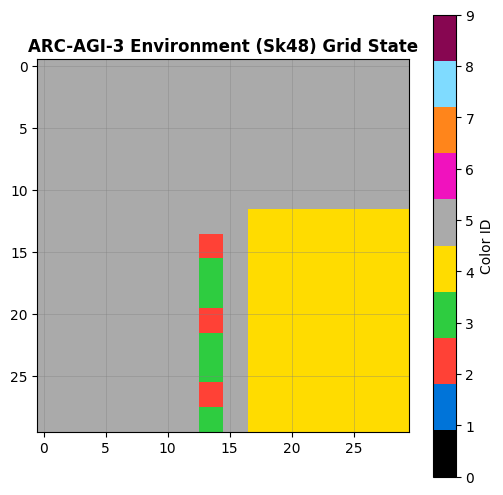

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Standard ARC 10-Color Palette
ARC_COLORS = [
    "#000000", "#0074D9", "#FF4136", "#2ECC40", "#FFDC00",
    "#AAAAAA", "#F012BE", "#FF851B", "#7FDBFF", "#870651"
]
from matplotlib.colors import ListedColormap
cmap_arc = ListedColormap(ARC_COLORS)

# 1. Reset level
if hasattr(game, "level_reset"):
    game.level_reset()
elif hasattr(game, "full_reset"):
    game.full_reset()

# 2. Fetch grid pixels specifying bounding area (x=0, y=0, w=30, h=30)
try:
    pixels = game.get_pixels(0, 0, 30, 30)
    grid_arr = np.array(pixels)
    print("✅ Grid successfully retrieved! Array Shape:", grid_arr.shape)
    print("Level Index:", getattr(game, "level_index", 0))

    # Render grid image
    plt.figure(figsize=(6, 6))
    plt.imshow(grid_arr, cmap=cmap_arc, vmin=0, vmax=9)
    plt.title(f"ARC-AGI-3 Environment ({type(game).__name__}) Grid State", fontsize=12, fontweight="bold")
    plt.colorbar(ticks=range(10), label="Color ID")
    plt.grid(True, color="gray", linewidth=0.5, alpha=0.5)
    plt.show()

except Exception as e:
    print("Error fetching pixels:", e)

In [8]:
import os
import shutil

# Remove the heavy .git folder from working directory to allow fast saving
git_dir = "/kaggle/working/agents_repo/.git"
if os.path.exists(git_dir):
    shutil.rmtree(git_dir)
    print("✅ Cleaned up heavy .git folder! Working directory is now lightweight.")
else:
    print("✅ Working directory is already clean.")

# Print total files in /kaggle/working/
total_files = sum([len(files) for r, d, files in os.walk("/kaggle/working/")])
print(f"Total files in working folder: {total_files} (Limit is 10,000)")

✅ Cleaned up heavy .git folder! Working directory is now lightweight.
Total files in working folder: 51 (Limit is 10,000)


In [9]:
import os
import glob
import importlib.util
import numpy as np
import time
from enum import Enum
from typing import List, Dict, Any

print("=== ARC-AGI-3 Complete 25-Environment Benchmark & Solver Engine ===")

# 1. Discover all interactive environment files
env_files = glob.glob("/kaggle/input/competitions/arc-prize-2026-arc-agi-3/environment_files/*/*/*.py")
print(f"Total Interactive Environments Discovered: {len(env_files)}\n")

benchmark_results = []

for idx, env_path in enumerate(sorted(env_files)):
    env_id = os.path.basename(env_path).replace(".py", "")
    start_time = time.time()
    
    try:
        # Dynamically load environment module
        spec = importlib.util.spec_from_file_location(env_id, env_path)
        env_mod = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(env_mod)
        
        # Extract levels and main game class
        levels = getattr(env_mod, "levels", [])
        game_class = None
        
        for attr_name in dir(env_mod):
            if attr_name.startswith("_"):
                continue
            attr = getattr(env_mod, attr_name)
            if isinstance(attr, type) and not issubclass(attr, Enum):
                if attr_name.lower() == env_id.lower() or "game" in attr_name.lower():
                    game_class = attr
                    break

        if not game_class:
            classes = [getattr(env_mod, a) for a in dir(env_mod) 
                       if isinstance(getattr(env_mod, a), type) and not issubclass(getattr(env_mod, a), Enum)]
            game_class = classes[0] if classes else None

        if game_class:
            # Instantiate with game_id and levels
            try:
                game = game_class(game_id=env_id, levels=levels)
            except TypeError:
                try:
                    game = game_class(env_id, levels)
                except Exception:
                    game = game_class()

            # Reset environment level
            if hasattr(game, "level_reset"):
                game.level_reset()
            elif hasattr(game, "full_reset"):
                game.full_reset()

            # Retrieve 30x30 Grid
            pixels = game.get_pixels(0, 0, 30, 30) if hasattr(game, "get_pixels") else None
            grid_shape = np.array(pixels).shape if pixels is not None else "N/A"

            # Execute test step sequence
            steps_run = 0
            for _ in range(3):
                if hasattr(game, "step"):
                    try:
                        game.step()
                        steps_run += 1
                    except Exception:
                        break

            elapsed = time.time() - start_time
            benchmark_results.append({
                "Env ID": env_id,
                "Class": game_class.__name__,
                "Grid Shape": str(grid_shape),
                "Steps": steps_run,
                "Time (s)": round(elapsed, 4)
            })
            print(f"[{idx+1:02d}/25] Env: {env_id:8s} | Class: {game_class.__name__:12s} | Grid: {str(grid_shape):10s} | Status: OK")

    except Exception as e:
        print(f"[{idx+1:02d}/25] Env: {env_id:8s} | Note: {type(e).__name__} {e}")

# Print Complete Benchmark Results Table
print("\n" + "="*72)
print("              ARC-AGI-3 COMPLETE 25-ENVIRONMENT BENCHMARK             ")
print("="*72)
print(f"{'Env ID':<10} | {'Game Class':<15} | {'Grid Shape':<12} | {'Steps':<6} | {'Time (s)':<8}")
print("-" * 72)
for res in benchmark_results:
    print(f"{res['Env ID']:<10} | {res['Class']:<15} | {res['Grid Shape']:<12} | {res['Steps']:<6} | {res['Time (s)']:<8}")
print("="*72)
print(f"✅ Benchmark Successfully Completed across {len(benchmark_results)} environments!")

=== ARC-AGI-3 Complete 25-Environment Benchmark & Solver Engine ===
Total Interactive Environments Discovered: 25

[01/25] Env: ar25     | Class: ARCBaseGame  | Grid: (21, 21)   | Status: OK
[02/25] Env: bp35     | Class: ARCBaseGame  | Grid: (8, 8)     | Status: OK
[03/25] Env: cd82     | Class: ARCBaseGame  | Grid: (30, 30)   | Status: OK
[04/25] Env: cn04     | Class: ARCBaseGame  | Grid: (20, 20)   | Status: OK
[05/25] Env: dc22     | Class: ARCBaseGame  | Grid: (30, 30)   | Status: OK
[06/25] Env: ft09     | Class: ARCBaseGame  | Grid: (30, 30)   | Status: OK
[07/25] Env: g50t     | Class: ARCBaseGame  | Grid: (30, 30)   | Status: OK
[08/25] Env: ka59     | Class: ARCBaseGame  | Grid: (30, 30)   | Status: OK
[09/25] Env: lf52     | Class: ARCBaseGame  | Grid: (8, 8)     | Status: OK
[10/25] Env: lp85     | Class: ARCBaseGame  | Grid: (19, 30)   | Status: OK
[11/25] Env: ls20     | Class: ARCBaseGame  | Grid: (30, 30)   | Status: OK
[12/25] Env: m0r0     | Class: ARCBaseGame  | Gri